<a href="https://colab.research.google.com/github/kalpana222/CodeAlpha_Car_Price_Prediction/blob/main/Car_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗💰 Car Price Prediction

CodeAlpha Data Science Internship

Name: Kalpana

Domain: Data Science

Project 3: Car Price Prediction with Machine Learning


## Project Objective

This project predicts the selling price of cars using machine learning techniques. It involves data cleaning, exploratory data analysis (EDA), feature engineering, model training, and evaluation. The project was completed as part of the **CodeAlpha Data Science Internship**.


### 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

### 2. Load the Dataset

In [2]:
df = pd.read_csv("car data.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (301, 9)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### 3. Data Cleaning

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [7]:
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (299, 9)


In [8]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [9]:
print(df.shape)
df.head()

(299, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### 4. Exploratory Data Analysis (EDA)

#### 📈 Distribution of Selling Price

This histogram shows how the selling prices of cars are distributed in the dataset. It helps identify whether most cars are low-priced or expensive and reveals the overall price distribution.

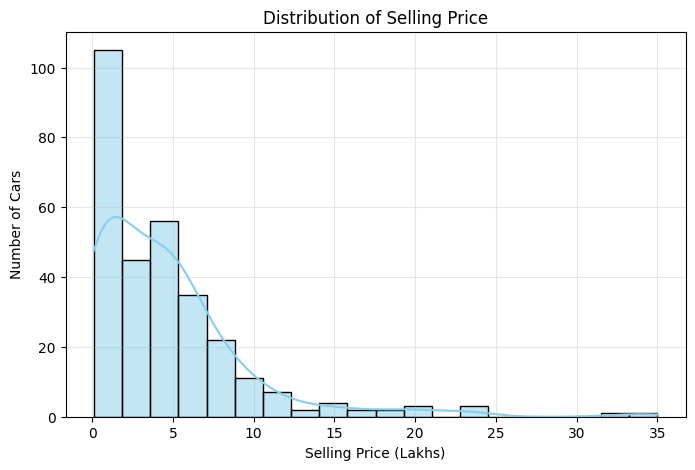

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Selling_Price", bins=20, kde=True, color="skyblue")
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.grid(alpha=0.3)
plt.show()

#### 🚗 Average Selling Price by Brand

This chart compares the average selling price of the top car brands in the dataset. It helps identify which brands generally have higher market value.

In [11]:
df["Brand"] = df["Car_Name"].str.split().str[0]

In [12]:
brand_price = (df.groupby("Brand")["Selling_Price"].mean().sort_values(ascending=False).head(10))

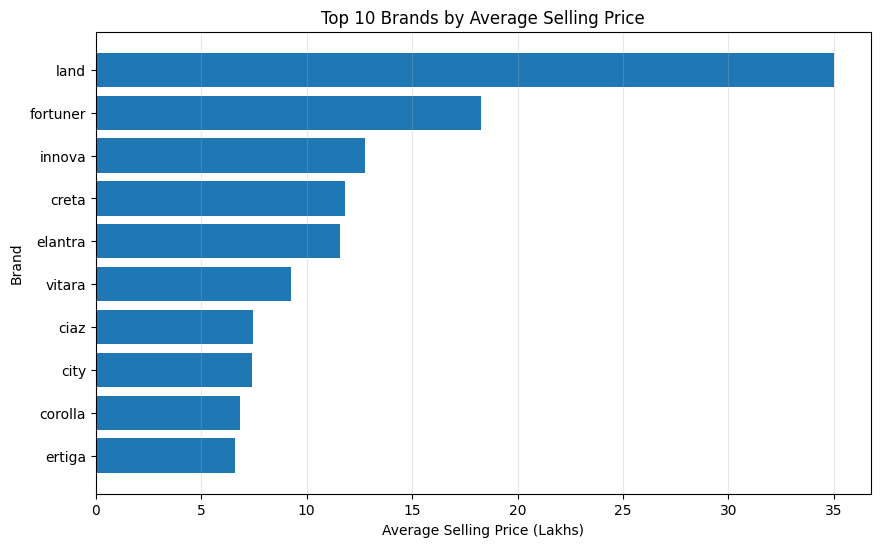

In [13]:
plt.figure(figsize=(10,6))
plt.barh(brand_price.index, brand_price.values)
plt.title("Top 10 Brands by Average Selling Price")
plt.xlabel("Average Selling Price (Lakhs)")
plt.ylabel("Brand")
plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

#### 💰 Present Price vs Selling Price

This scatter plot shows the relationship between the current showroom price and the selling price. It helps understand how the original price influences resale value.

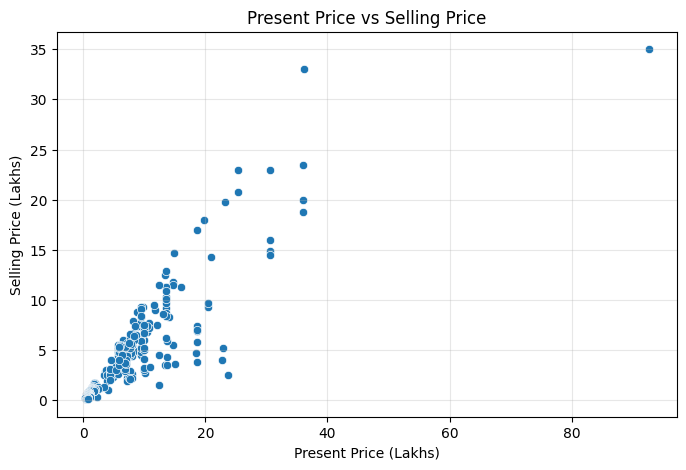

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price")
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Selling Price (Lakhs)")
plt.grid(alpha=0.3)
plt.show()

#### 🚘 Driven Kilometers vs Selling Price

This scatter plot shows how the number of kilometers driven affects the selling price of a car.

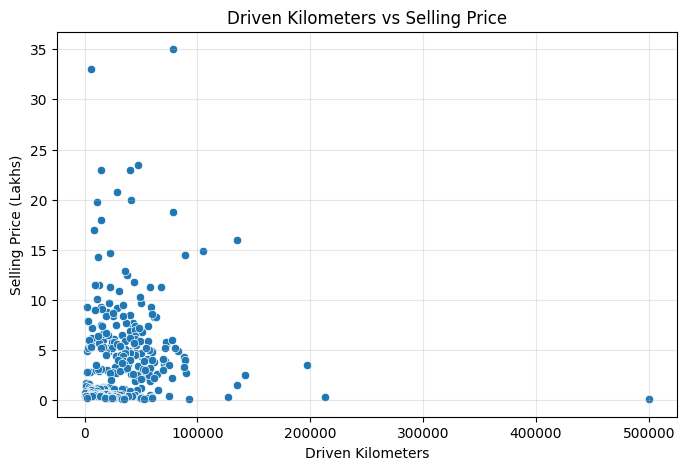

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price")
plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price (Lakhs)")
plt.grid(alpha=0.3)
plt.show()

#### ⛽ Selling Price by Fuel Type

This box plot compares the selling prices of cars based on their fuel type. It helps analyze how Petrol, Diesel, and CNG vehicles differ in resale value.

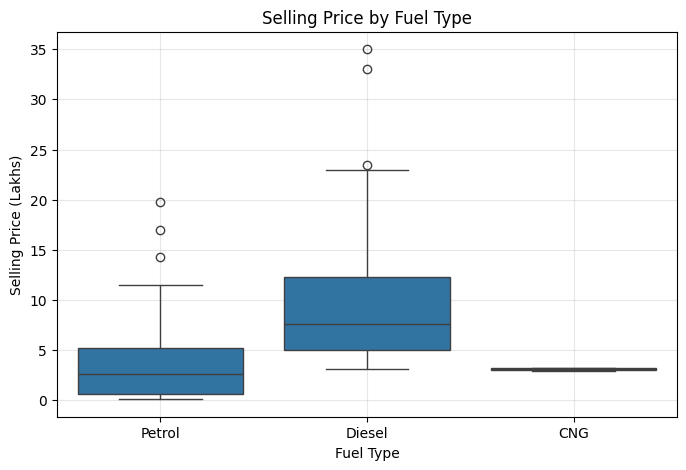

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Fuel_Type",y="Selling_Price")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")
plt.grid(alpha=0.3)
plt.show()

#### ⚙️ Selling Price by Transmission Type

This box plot compares the selling prices of cars with Manual and Automatic transmissions. It helps determine whether transmission type affects resale value.

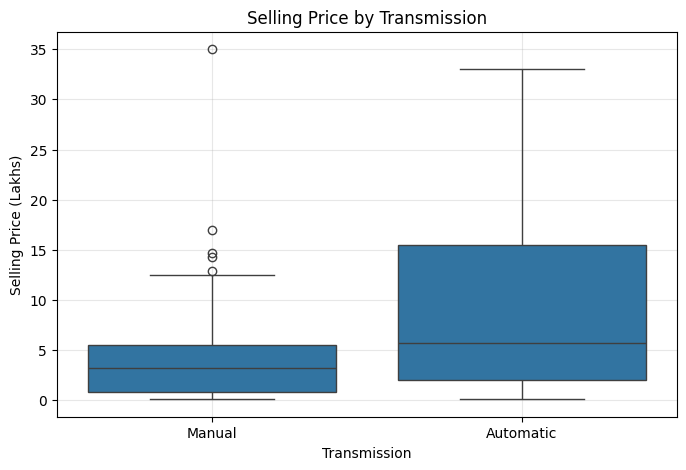

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Transmission",y="Selling_Price")
plt.title("Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Selling Price (Lakhs)")
plt.grid(alpha=0.3)
plt.show()

#### 🔥 Correlation Heatmap

This heatmap shows the correlation between numerical features in the dataset. It helps identify which variables have the strongest relationship with the selling price.

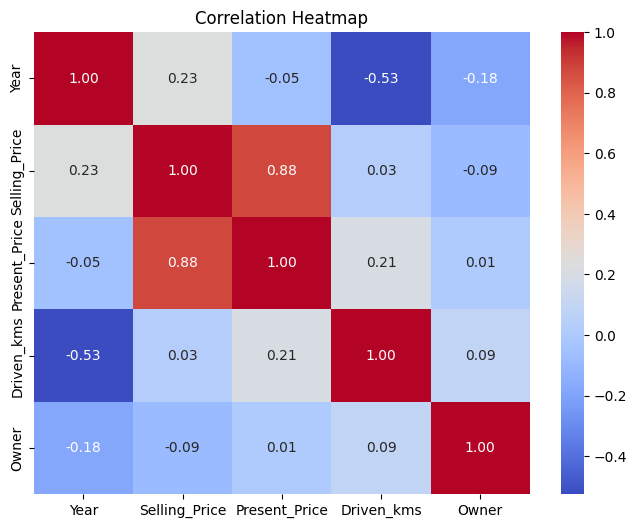

In [18]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 5. Data Preprocessing

In [19]:
le = LabelEncoder()
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Selling_type"] = le.fit_transform(df["Selling_type"])
df["Transmission"] = le.fit_transform(df["Transmission"])
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0     ritz  2014           3.35           5.59       27000          2   
1      sx4  2013           4.75           9.54       43000          1   
2     ciaz  2017           7.25           9.85        6900          2   
3  wagon r  2011           2.85           4.15        5200          2   
4    swift  2014           4.60           6.87       42450          1   

   Selling_type  Transmission  Owner  Brand  
0             0             1      0   ritz  
1             0             1      0    sx4  
2             0             1      0   ciaz  
3             0             1      0  wagon  
4             0             1      0  swift  


In [20]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Brand
0,ritz,2014,3.35,5.59,27000,2,0,1,0,ritz
1,sx4,2013,4.75,9.54,43000,1,0,1,0,sx4
2,ciaz,2017,7.25,9.85,6900,2,0,1,0,ciaz
3,wagon r,2011,2.85,4.15,5200,2,0,1,0,wagon
4,swift,2014,4.60,6.87,42450,1,0,1,0,swift


In [21]:
df = df.drop("Car_Name", axis=1)
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Brand
0,2014,3.35,5.59,27000,2,0,1,0,ritz
1,2013,4.75,9.54,43000,1,0,1,0,sx4
2,2017,7.25,9.85,6900,2,0,1,0,ciaz
3,2011,2.85,4.15,5200,2,0,1,0,wagon
4,2014,4.60,6.87,42450,1,0,1,0,swift


In [24]:
df["Brand"] = le.fit_transform(df["Brand"])
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Brand
0,2014,3.35,5.59,27000,2,0,1,0,36
1,2013,4.75,9.54,43000,1,0,1,0,39
2,2017,7.25,9.85,6900,2,0,1,0,18
3,2011,2.85,4.15,5200,2,0,1,0,42
4,2014,4.60,6.87,42450,1,0,1,0,38


In [28]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [29]:
print(X.head())
print(y.head())

   Year  Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  \
0  2014           5.59       27000          2             0             1   
1  2013           9.54       43000          1             0             1   
2  2017           9.85        6900          2             0             1   
3  2011           4.15        5200          2             0             1   
4  2014           6.87       42450          1             0             1   

   Owner  Brand  
0      0     36  
1      0     39  
2      0     18  
3      0     42  
4      0     38  
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (239, 8)
Testing Features : (60, 8)
Training Target  : (239,)
Testing Target   : (60,)


### 6. Machine Learning Models

In this section, three machine learning regression models are trained to predict the selling price of cars. The models are evaluated using standard regression metrics, and their performances are compared to determine which model provides the most accurate predictions.

#### 📈 Linear Regression

Linear Regression is one of the simplest and most widely used regression algorithms. It predicts the selling price by finding a linear relationship between the input features and the target variable.

In [31]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

#### 🌳 Decision Tree Regressor

Decision Tree Regressor predicts the selling price by splitting the dataset into smaller decision rules. It can capture complex relationships between features without assuming a linear relationship.

In [32]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

#### 🌲 Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [33]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

### 7. Model Evaluation
In this section, the performance of all three regression models is evaluated using standard regression metrics. The models are compared based on Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score to identify the most accurate model for predicting car selling prices.

#### 📈 Linear Regression Performance
The Linear Regression model is evaluated using four standard regression metrics to measure its prediction accuracy.


In [34]:
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-" * 35)
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Performance
-----------------------------------
MAE : 1.5624008730943637
MSE : 6.756929168711665
RMSE: 2.5994093884403173
R² Score: 0.7378318231331342


#### 🌳 Decision Tree Performance
The Decision Tree Regressor is evaluated using the same regression metrics for comparison with the other models.

In [35]:
dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Performance")
print("-" * 35)
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Performance
-----------------------------------
MAE : 1.3119999999999998
MSE : 8.52823
RMSE: 2.9203133393524743
R² Score: 0.6691055277959035


#### 🌲 Random Forest Performance
The Random Forest Regressor is evaluated using the same performance metrics. It generally provides better prediction accuracy by combining multiple decision trees.

In [36]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-" * 35)
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
-----------------------------------
MAE : 1.2939733333333343
MSE : 9.963142852333338
RMSE: 3.1564446537731876
R² Score: 0.6134310524438418


#### Model Comparison
The table below compares the performance of all three machine learning models. Lower values of MAE, MSE, and RMSE indicate better prediction accuracy, while a higher R² Score represents a better model fit.

In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "MSE": [
        lr_mse,
        dt_mse,
        rf_mse
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,1.562401,6.756929,2.599409,0.737832
1,Decision Tree,1.312000,8.528230,2.920313,0.669106
2,Random Forest,1.293973,9.963143,3.156445,0.613431


### 8. Price Prediction

In this section, the trained Linear Regression model is used to predict the selling price of a car based on its features. This demonstrates how machine learning models can estimate the resale value of vehicles using historical data.

In [40]:
new_car = pd.DataFrame({
    "Year": [2018],
    "Present_Price": [8.50],
    "Driven_kms": [25000],
    "Fuel_Type": [2],
    "Selling_type": [0],
    "Transmission": [1],
    "Owner": [0],
    "Brand": [38]
})
predicted_price = lr_model.predict(new_car)
print("Predicted Selling Price: {:.2f} Lakhs".format(predicted_price[0]))

Predicted Selling Price: 6.81 Lakhs


In [44]:
new_car2 = pd.DataFrame({
    "Year": [2015],
    "Present_Price": [12.50],
    "Driven_kms": [60000],
    "Fuel_Type": [1],
    "Selling_type": [0],
    "Transmission": [0],
    "Owner": [1],
    "Brand": [20]
})
predicted_price2 = lr_model.predict(new_car2)
print("Predicted Selling Price: {:.2f} Lakhs".format(predicted_price2[0]))

Predicted Selling Price: 10.46 Lakhs


#### Prediction Summary
The Linear Regression model successfully predicted the selling prices of different cars based on their features. The predicted values demonstrate how machine learning can estimate vehicle resale prices by considering factors such as manufacturing year, current showroom price, kilometers driven, fuel type, transmission, ownership history, and brand. This highlights the practical application of regression models in real-world price prediction tasks.

# Conclusion

This project successfully developed a machine learning model to predict the selling price of cars based on various features such as manufacturing year, present price, kilometers driven, fuel type, selling type, transmission, ownership history, and brand.

The project followed a complete machine learning workflow, including data understanding, data cleaning, exploratory data analysis (EDA), data preprocessing, feature encoding, model training, and performance evaluation. Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were trained and compared using standard evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

Among the three models, **Linear Regression** achieved the best overall performance for this dataset and was selected as the final model for predicting car selling prices. The project demonstrates how machine learning can assist in estimating vehicle resale values and support informed decision-making in the automotive industry.